In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [12]:
df = pd.read_csv("datasets/SMSSpamCollection", sep='\t', names=['label', 'text'])
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Separate the input and output variables

In [14]:
x = df['text']
y = df['label']

#### Explore the data 

In [15]:
set(y)

{'ham', 'spam'}

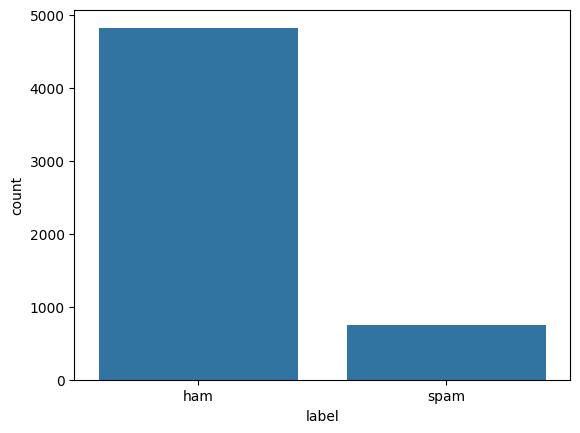

In [19]:
sns.countplot(x=y);

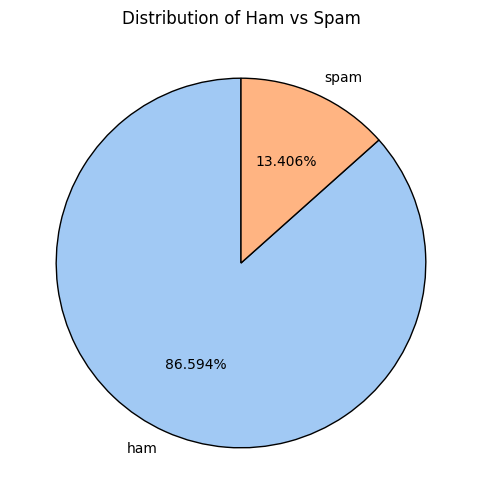

In [31]:
label_counts = df['label'].value_counts()
colors = sns.color_palette('pastel')[0:len(label_counts)]

plt.figure(figsize=(6, 6))
plt.pie(label_counts, 
        labels=label_counts.index, 
        autopct='%3.3f%%', 
        startangle=90, 
        colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Distribution of Ham vs Spam')
plt.show()

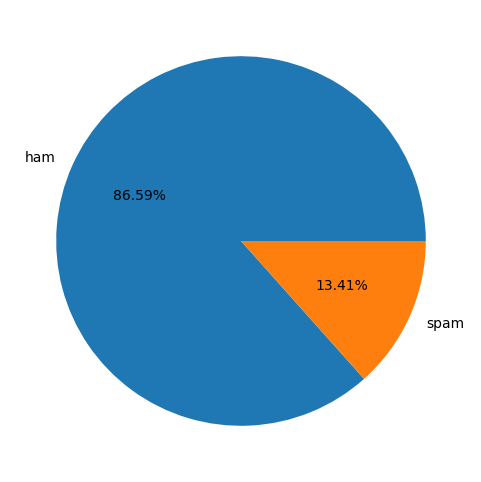

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%2.2f%%');

### Data Preprocessing

#### Data Cleaning

In [49]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer, PorterStemmer
from nltk import pos_tag

In [50]:
# Sample text data
sent = 'Hello friends! How are you? I like Python Programming.'

In [51]:
# 1. Tokenize the data
tokens1 = word_tokenize(sent)
print("Original Tokens:", tokens1)

Original Tokens: ['Hello', 'friends', '!', 'How', 'are', 'you', '?', 'I', 'like', 'Python', 'Programming', '.']


In [52]:
# 2. Remove punctuation and numbers
tokens2 = [token for token in tokens1 if token.isalpha()]
print("Cleaned Tokens:", tokens2)

Cleaned Tokens: ['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'Programming']


In [53]:
#Remove Stopwords
tokens3 = [token.lower() for token in tokens2 if token.lower() not in stopwords.words('english')]
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [57]:
#Apply Stemming
ps = PorterStemmer()
tokens4 = [ps.stem(token) for token in tokens3]
print(tokens4)

['hello', 'friend', 'like', 'python', 'program']


In [60]:
def clean_text(sent):
    # tokenize the data
    tokens1 = word_tokenize(sent)
    
    # remove punctuation and numbers
    tokens2 = [token for token in tokens1 if token.isalpha()]
    
    # remove stopwords
    tokens3 = [token.lower() for token in tokens2
               if token.lower() not in stopwords.words('english')]
               
    tokens4 = [ps.stem(token) for token in tokens3]
    return tokens4

clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [61]:
sent1 = 'It was an unexpected rain during the play on ground.'
clean_text(sent1)

['unexpect', 'rain', 'play', 'ground']